# Student lifystyle clustering project

## Imports and Exploration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#setting overall plotting style and figure size for consistent visualization

plt.rcParams['figure.figsize']=(12,4)
plt.style.use('bmh')

sns.set_style('whitegrid')

In [6]:
df=pd.read_csv(r'D:\Codes\Mopi.py\MachineLearning\UnsupervisedLearning\student\student_lifestyle_100k.csv')
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [7]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [9]:
df.shape

(100000, 11)

In [10]:
df=df.drop('Student_ID',axis=1)
df.columns

Index(['Age', 'Gender', 'Department', 'CGPA', 'Sleep_Duration', 'Study_Hours',
       'Social_Media_Hours', 'Physical_Activity', 'Stress_Level',
       'Depression'],
      dtype='object')

In [11]:
#encoding Gender column for better usability

df['Gender']=df['Gender'].map({'Female':0,'Male':1})
df['Gender'].value_counts()

Gender
1    50120
0    49880
Name: count, dtype: int64

In [12]:
#getting basic distributions

for column in df.columns :
    if df[column].nunique()<50 :
        print(df[column].value_counts())

Age
22    14462
24    14393
23    14285
19    14263
21    14207
18    14197
20    14193
Name: count, dtype: int64
Gender
1    50120
0    49880
Name: count, dtype: int64
Department
Science        20071
Engineering    20057
Arts           19998
Medical        19964
Business       19910
Name: count, dtype: int64
Stress_Level
5     24525
4     23326
3     22666
2     13591
6     11653
7      2255
8      1506
9       474
10        4
Name: count, dtype: int64
Depression
False    89938
True     10062
Name: count, dtype: int64


In [13]:
df['Depression']=df['Depression'].astype(int)

In [14]:
df['Depression'].value_counts()

Depression
0    89938
1    10062
Name: count, dtype: int64

## Exploraty Data Analysis

### Basic EDA

In [17]:
#comparing feature spreads to understand variability between students

for column in df.columns :
    if column not in ['Depression','Department'] :
        print(df.groupby('Depression')[column].mean())
        print(f'Mean : {df[column].mean()}',end='\n\n')

Depression
0    21.014176
1    20.962830
Name: Age, dtype: float64
Mean : 21.00901

Depression
0    0.500445
1    0.507951
Name: Gender, dtype: float64
Mean : 0.5012

Depression
0    2.930177
1    2.613530
Name: CGPA, dtype: float64
Mean : 2.8983157

Depression
0    7.025263
1    6.738660
Name: Sleep_Duration, dtype: float64
Mean : 6.996425000000001

Depression
0    4.520047
1    4.415395
Name: Study_Hours, dtype: float64
Mean : 4.509517

Depression
0    3.494948
1    3.577837
Name: Social_Media_Hours, dtype: float64
Mean : 3.503288

Depression
0    74.555305
1    72.546512
Name: Physical_Activity, dtype: float64
Mean : 74.35318

Depression
0    4.095521
1    4.454681
Name: Stress_Level, dtype: float64
Mean : 4.13166



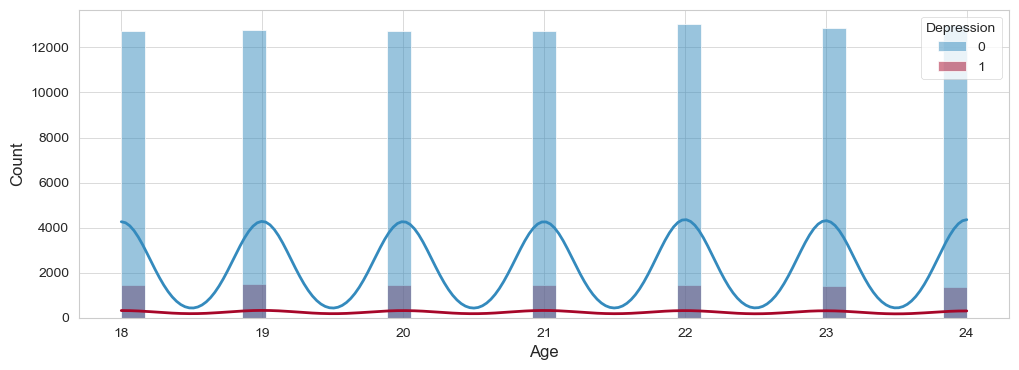

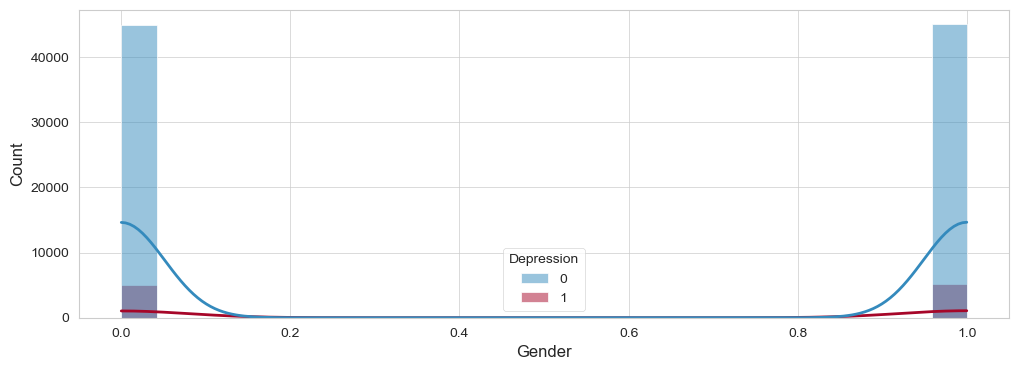

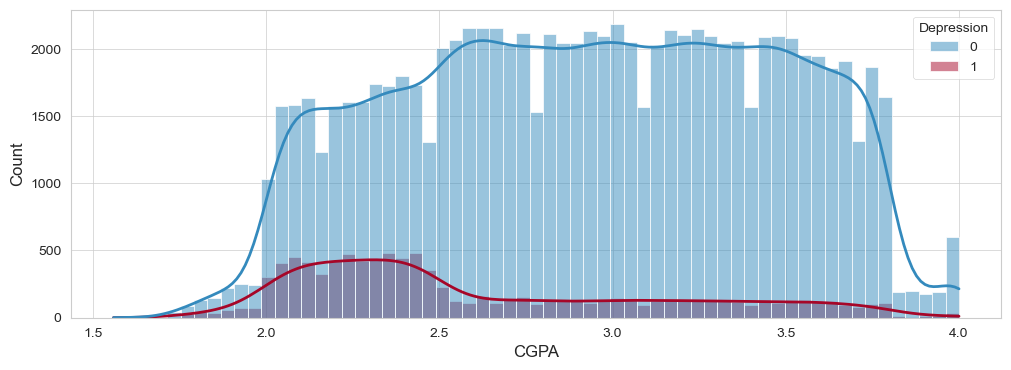

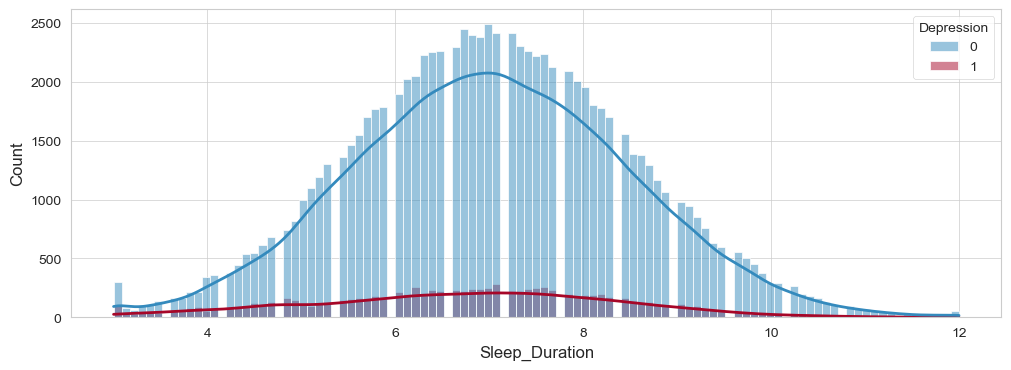

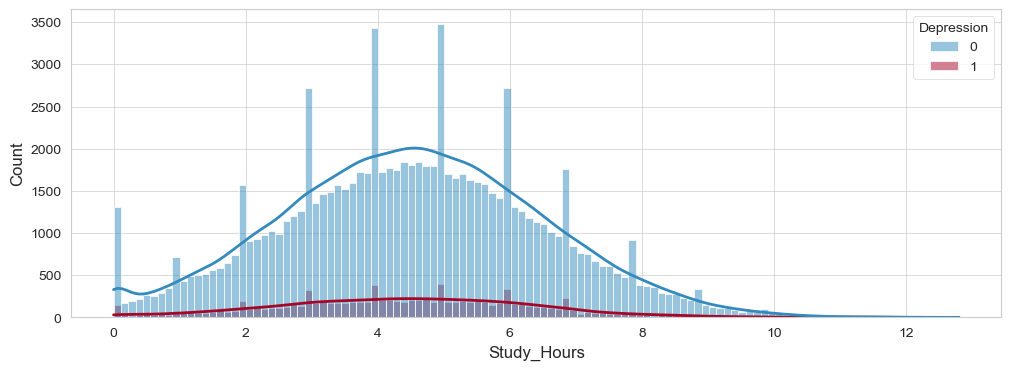

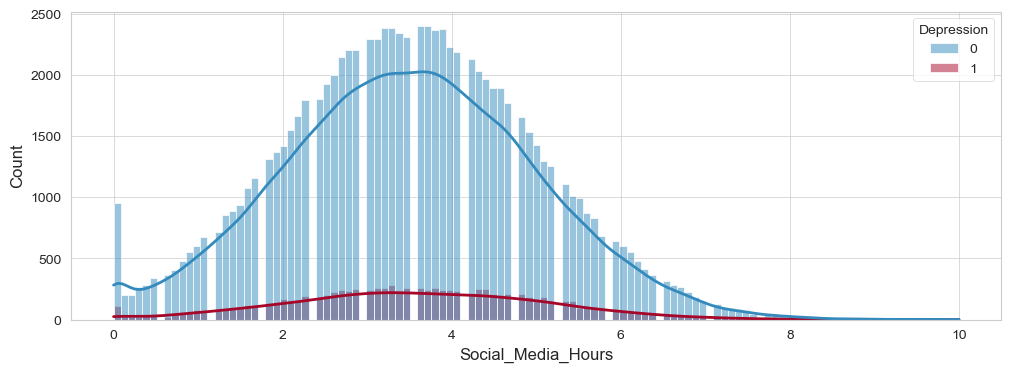

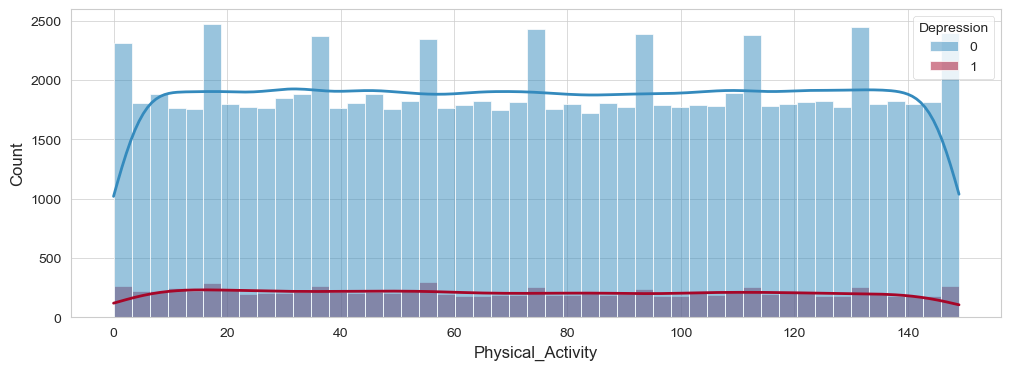

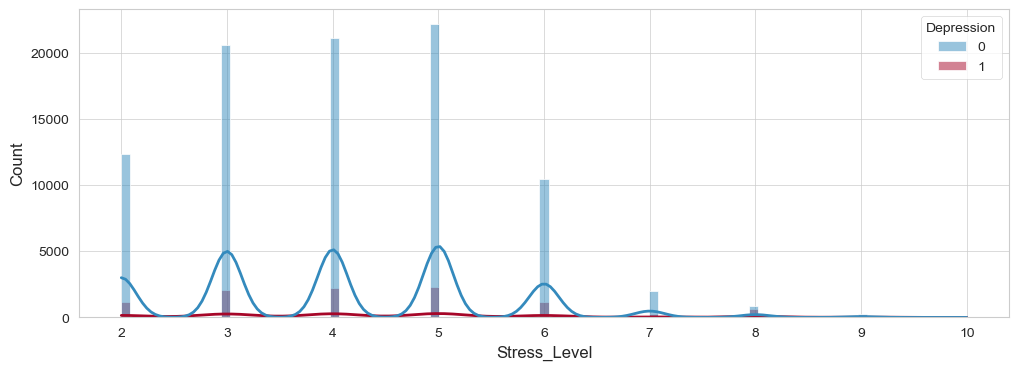

In [18]:
#anslysing linear relationships between numeric features

for column in df.columns :
    if column!='Department' and column!='Depression':
        sns.histplot(
            data=df,
            x=column,
            hue='Depression',
            kde=True
        )
        plt.show()

<Axes: >

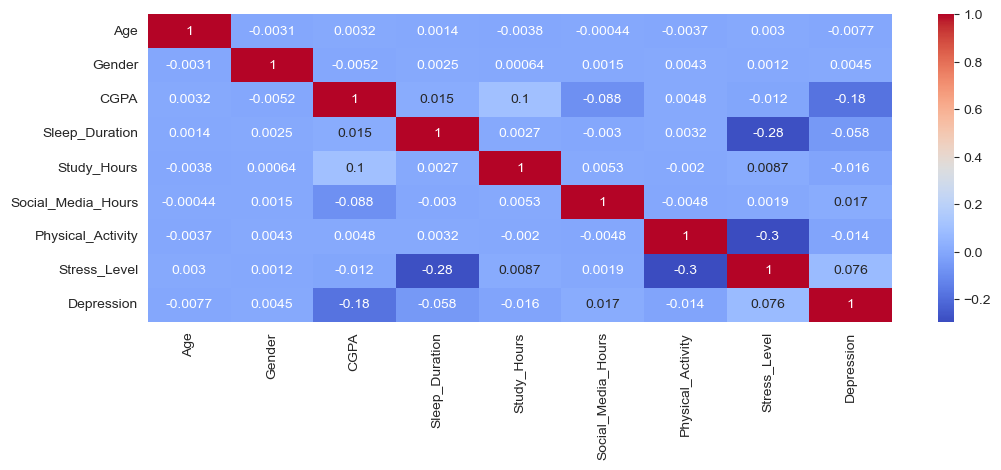

In [19]:
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm',annot=True)

<Axes: xlabel='Sleep_Duration', ylabel='Stress_Level'>

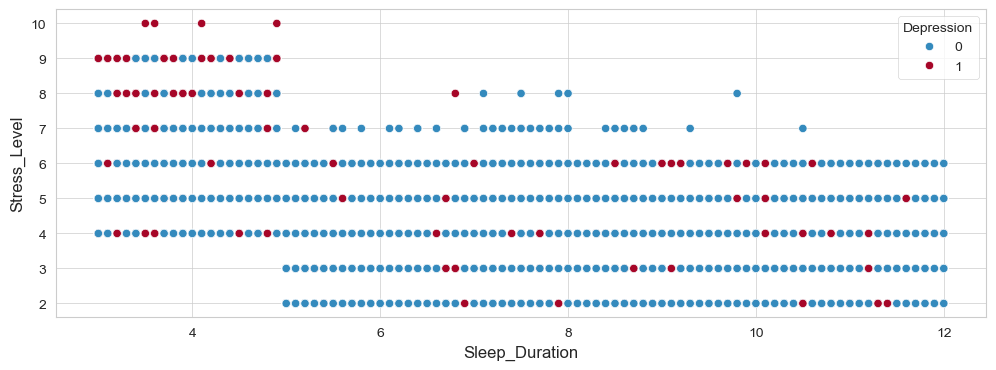

In [20]:
sns.scatterplot(
    x='Sleep_Duration',
    y='Stress_Level',
    hue='Depression',
    data=df
)

In [21]:
dep_depart=df.groupby(['Department','Depression']).mean()
dep_depart

Age    Gender      CGPA  Sleep_Duration  \
Department  Depression                                                  
Arts        0           21.025935  0.499276  2.934243        7.029041   
            1           20.979310  0.502463  2.623734        6.731232   
Business    0           21.012191  0.498937  2.930306        7.026535   
            1           20.960059  0.518738  2.609936        6.683333   
Engineering 0           21.025448  0.503742  2.927316        7.016937   
            1           20.900990  0.501485  2.627644        6.756980   
Medical     0           21.005340  0.503755  2.928584        7.030211   
            1           20.940111  0.517363  2.601726        6.753951   
Science     0           21.001992  0.496514  2.930445        7.023636   
            1           21.034051  0.499750  2.604276        6.768653   

                        Study_Hours  Social_Media_Hours  Physical_Activity  \
Department  Depression                                                       
Arts        0              4.515644            3.487678          74.945403   
            1              4.407389            3.598621          73.514778   
Business    0              4.550324            3.489392          74.667375   
            1              4.580819            3.569280          72.607988   
Engineering 0              4.494883            3.497755          74.801852   
            1              4.359109            3.590297          71.274752   
Medical     0              4.521094            3.500111          74.284641   
            1              4.326120            3.561147          73.452441   
Science     0              4.518540            3.499734          74.079783   
            1              4.401302            3.569404          71.884827   

                        Stress_Level  
Department  Depression                
Arts        0               4.092275  
            1               4.448276  
Business    0               4.096689  
            1               4.457594  
Engineering 0               4.090425  
            1               4.448515  
Medical     0               4.089781  
            1               4.436336  
Science     0               4.108388  
            1               4.482724

In [22]:
dep_depart=df.groupby(['Department','Depression']).size()
dep_depart

Department   Depression
Arts         0             17968
             1              2030
Business     0             17882
             1              2028
Engineering  0             18037
             1              2020
Medical      0             17977
             1              1987
Science      0             18074
             1              1997
dtype: int64

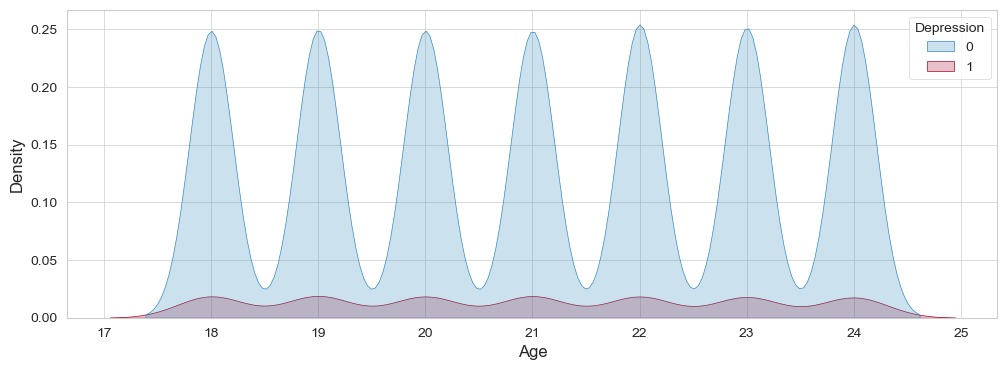

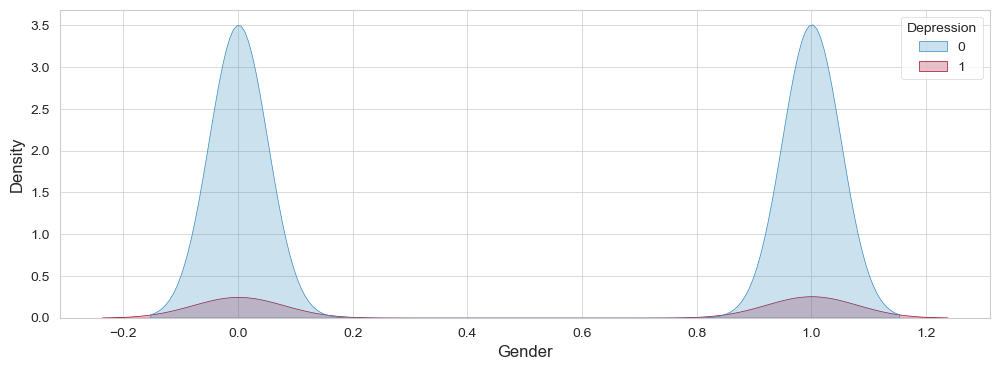

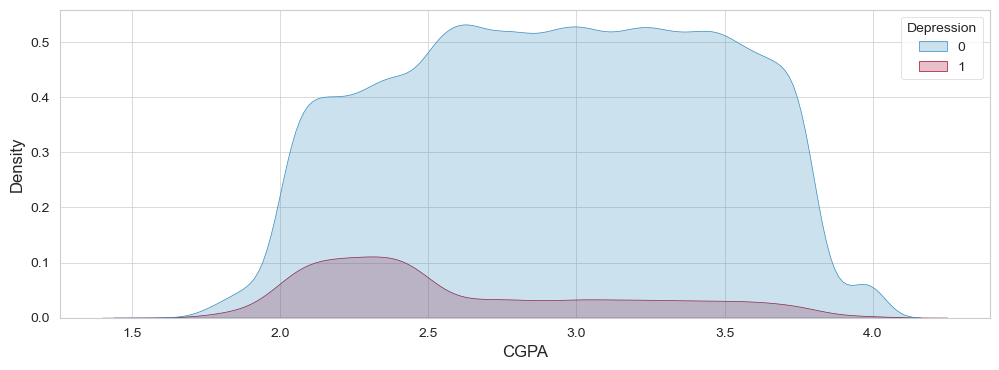

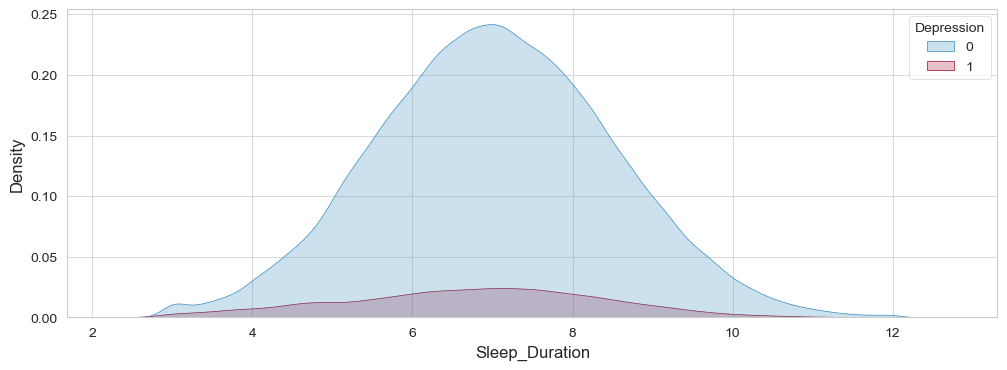

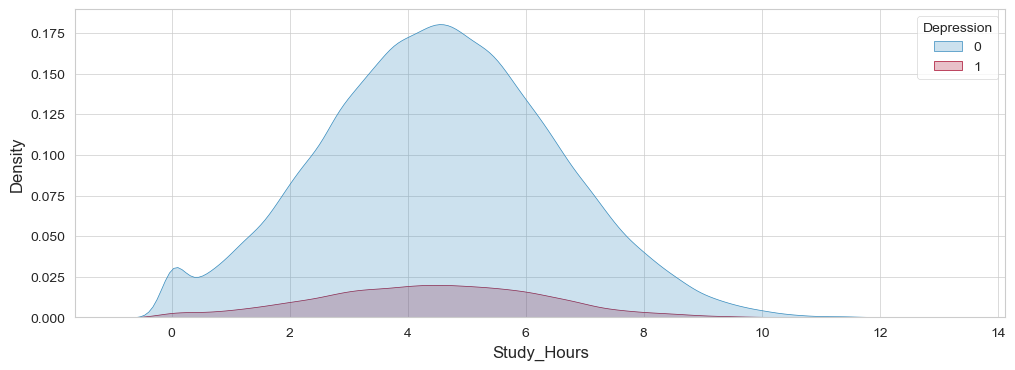

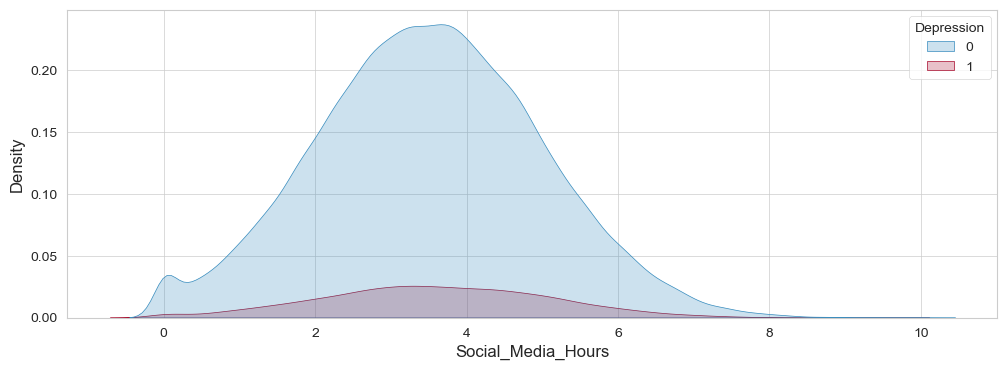

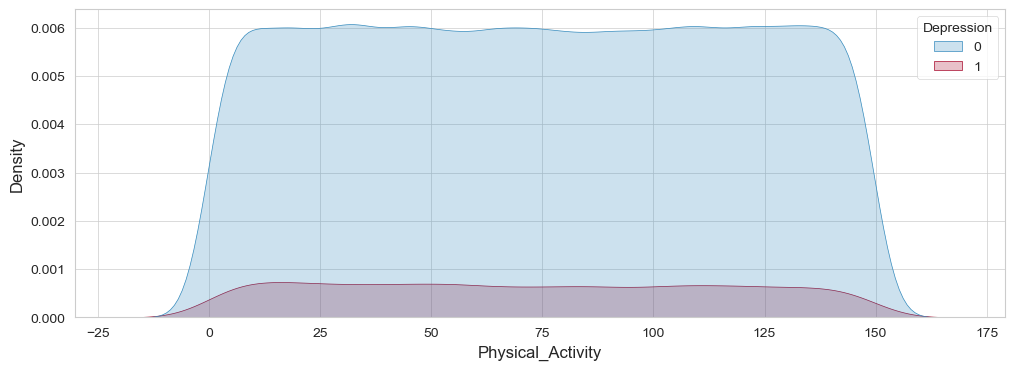

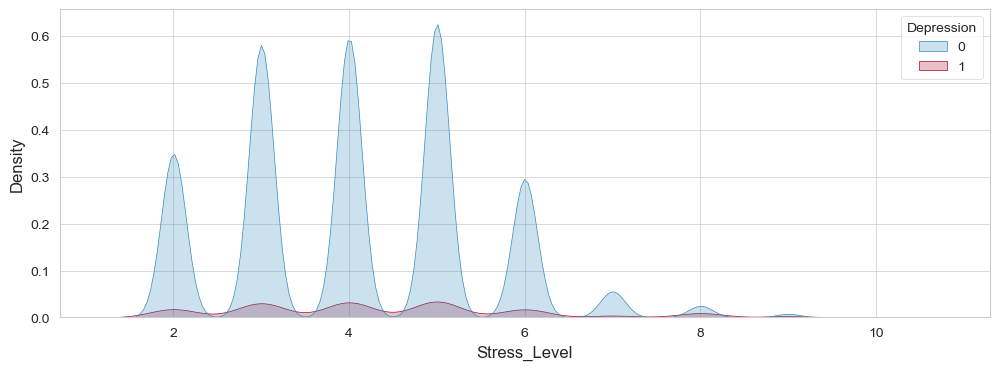

In [23]:
for column in df.columns :
    if column not in ['Depression','Department'] :
        sns.kdeplot(
            data=df,
            x=column,
            hue='Depression',
            fill=True
        )
        plt.show()

<Axes: xlabel='Department', ylabel='count'>

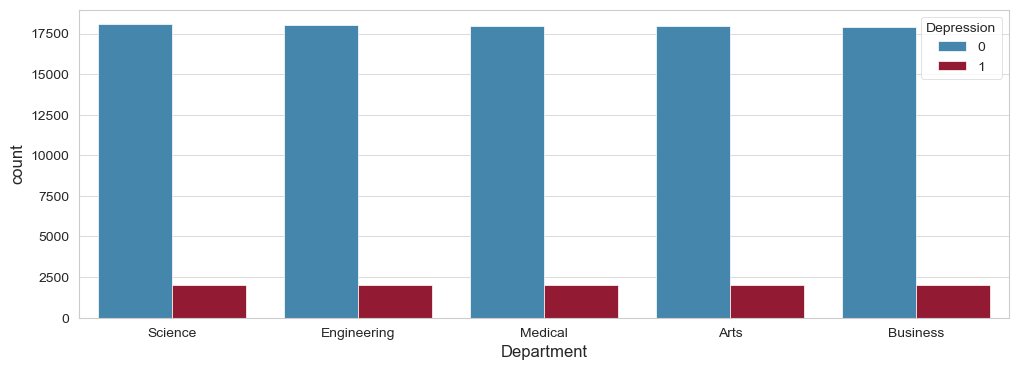

In [24]:
#compare depression percentage across departments
sns.countplot(x='Department',hue='Depression',data=df)

### Study hours & sleep duration connection

In [26]:
print(df['Study_Hours'].nunique(),df['Sleep_Duration'].nunique())

126 91


In [27]:
df[['Study_Hours','Sleep_Duration']].describe()

,Study_Hours,Sleep_Duration
count,100000.000000,100000.000000
mean,4.509517,6.996425
std,1.976076,1.498682
min,0.000000,3.000000
25%,3.200000,6.000000
50%,4.500000,7.000000
75%,5.800000,8.000000
max,12.800000,12.000000


In [28]:
print(df['Study_Hours'].unique(),df['Sleep_Duration'].unique())

[ 3.3  7.2  2.3  2.   2.6  3.5  4.   3.4  8.6  1.5  4.4  6.5  4.9  0.6
  5.9  3.8  3.6  3.1  0.8  4.8  2.4  3.7  7.9  0.3  3.   4.5  7.3  6.6
  5.7  6.2  4.3  1.1  1.6  7.   4.2  3.2  0.5  5.5  5.4  5.2  4.6  6.9
  1.3  6.4  0.   6.1  2.9  2.8  6.3  8.7  1.4  7.4  1.9  4.1  6.   1.7
  6.7  3.9  5.6  2.7  7.6  4.7  5.8  2.1  7.5  2.2  0.9  1.8  5.1  7.8
  5.   7.7  9.6  5.3  8.   7.1  6.8  1.2  8.3  0.7  2.5  0.1  8.2  9.3
  0.4  9.7  8.5  9.2  9.1  9.   8.4  9.4  8.9 10.2  8.8 10.1  1.   0.2
  9.9  9.5  8.1 10.  10.3 11.2 11.5 10.4 11.  11.3 10.9 11.6  9.8 11.1
 11.4 10.8 11.9 11.8 10.7 10.5 12.2 12.3 10.6 11.7 12.6 12.  12.8 12.1] [ 7.3  5.5  5.4  8.1  6.8  6.5  4.4  7.   4.8  5.7  3.8  5.1  7.6  5.3
  5.9  7.9  9.9  6.  10.7  8.4  4.9 10.5  9.1  8.5  6.2  8.6  6.3  7.1
  8.   7.4  4.6  6.9  6.4  4.5  9.3  7.5  9.6  7.8  8.2  3.   4.2  6.6
  6.1  5.8  6.7  3.6  8.8  8.9  5.6 10.   4.7  9.   8.3  7.2  5.2  4.
  9.2  9.5  5.   8.7 10.9  7.7  3.4 11.6  4.1 10.3  3.1  3.2 10.6  4.3
 10.1 

In [29]:
#getting average study hours for students with diffrent sleep hours

df['Study_Hours_rounded']=df['Study_Hours'].round()
study_sleep=(
    df.groupby('Study_Hours_rounded')
    .agg(avg_sleep=('Sleep_Duration','mean'),
    student_count=('Sleep_Duration','size'))
)

In [30]:
study_sleep

,avg_sleep,student_count
Study_Hours_rounded,,
0.0,6.945127,2411
1.0,6.987462,3948
2.0,6.990611,9958
3.0,6.991032,13648
4.0,6.996516,20981
5.0,7.008614,17356
6.0,7.014116,16535
7.0,6.973820,8155
8.0,6.996067,4856


In [31]:
#getting average sleep hours for students with diffrent study hours 

df['Sleep_Hours_rounded']=df['Sleep_Duration'].round()
sleep_study=(
    df.groupby('Sleep_Hours_rounded')
    .agg(avg_study=('Study_Hours','mean'),
    student_count=('Study_Hours','size'))
)

In [32]:
sleep_study

,avg_study,student_count
Sleep_Hours_rounded,,
3.0,4.508370,908
4.0,4.482777,4343
5.0,4.490853,9970
6.0,4.513630,23132
7.0,4.521030,23547
8.0,4.499135,23012
9.0,4.522105,9966
10.0,4.521885,4213
11.0,4.480054,737


In [33]:
df=df.drop(columns=['Study_Hours_rounded','Sleep_Hours_rounded'])

### Stress level breakdown

<Axes: xlabel='Department', ylabel='Stress_Level'>

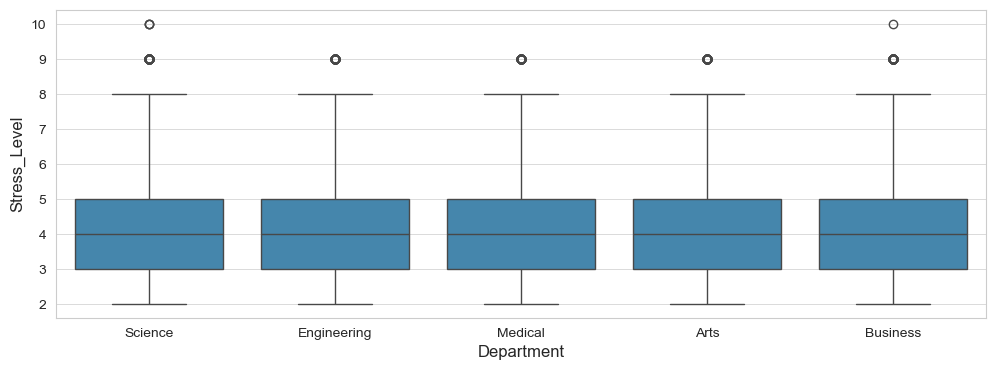

In [35]:
sns.boxplot(
    x='Department',
    y='Stress_Level',
    data=df
)

In [36]:
#seperating highly stressed students to find a relationship with their department

high_stress=df[df['Stress_Level']>=7]
high_stress.groupby('Department').size()

Department
Arts           867
Business       859
Engineering    848
Medical        844
Science        821
dtype: int64

In [37]:
high_stress_percent=(
    df.assign(High_stress=df['Stress_Level']>7)
    .groupby('Department')['High_stress']
    .mean()*100
)
high_stress_percent

Department
Arts           1.945195
Business       1.993973
Engineering    1.984345
Medical        2.023643
Science        1.972996
Name: High_stress, dtype: float64

<Axes: xlabel='Physical_Activity', ylabel='Stress_Level'>

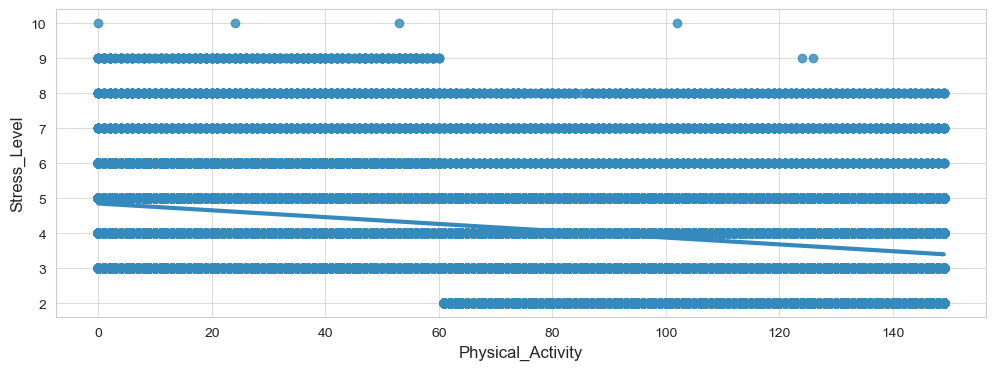

In [38]:
sns.regplot(
    x='Physical_Activity',
    y='Stress_Level',
    data=df
)

In [39]:
len(df[df['Stress_Level']>=9])

478

In [40]:
df['Stress_Level'].value_counts()

Stress_Level
5     24525
4     23326
3     22666
2     13591
6     11653
7      2255
8      1506
9       474
10        4
Name: count, dtype: int64

<Axes: xlabel='Physical_Activity', ylabel='Stress Average'>

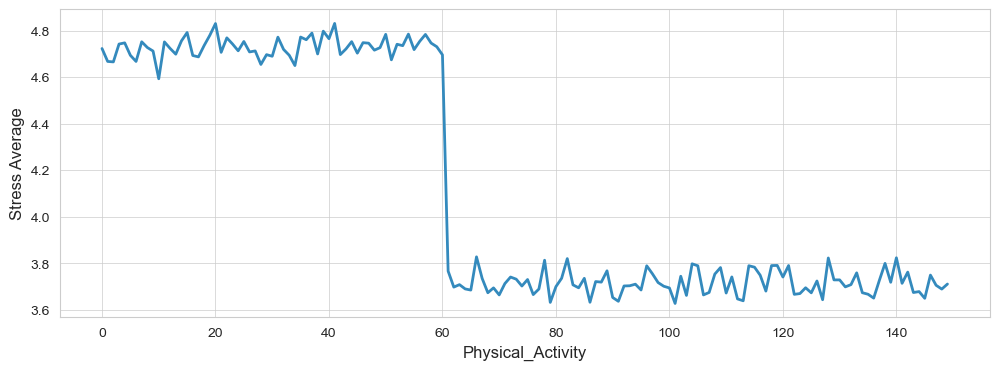

In [41]:
activity_stress=(
    df.groupby('Physical_Activity')['Stress_Level']
    .mean()
)
activity_stress.plot(ylabel='Stress Average')

### Physical activity breakdown

In [43]:
df.groupby('Physical_Activity').size()

Physical_Activity
0      620
1      673
2      645
3      639
4      676
      ... 
145    646
146    660
147    650
148    690
149    669
Length: 150, dtype: int64

<Axes: xlabel='Depression', ylabel='Physical_Activity'>

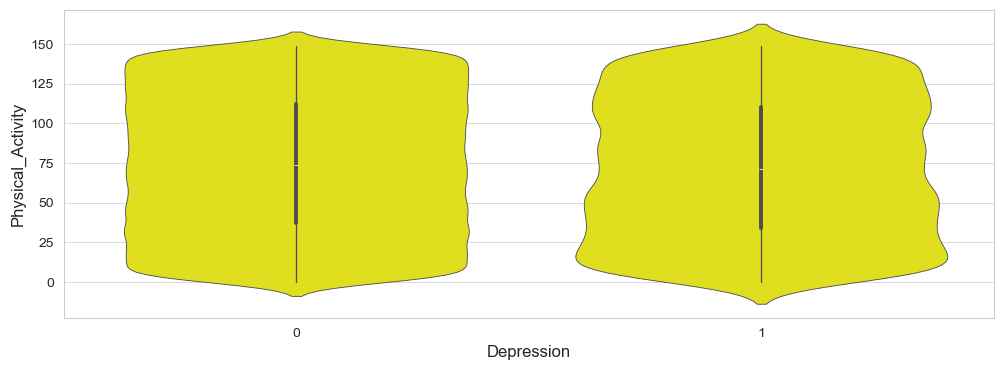

In [44]:
#breaking down connection between physical activity and depression

sns.violinplot(
    x='Depression',
    y='Physical_Activity',
    data=df,
    color='yellow'
)

In [45]:
df.groupby('Depression')['Physical_Activity'].agg(['mean','count','std'])

,mean,count,std
Depression,,,
0,74.555305,89938,43.342772
1,72.546512,10062,43.543096


In [46]:
df['Physical_Activity'].describe()

count    100000.000000
mean         74.353180
std          43.366963
min           0.000000
25%          37.000000
50%          74.000000
75%         112.000000
max         149.000000
Name: Physical_Activity, dtype: float64

In [47]:
#grouping diffrent physical activity values to see which one has the most depression

df['activity_group']=pd.cut(
    df['Physical_Activity'],
    bins=[0,30,60,90,120,150],
    labels=[
        'very_low',
        'low',
        'moderate',
        'high',
        'very_high'
    ]
)
df['activity_group'].value_counts()

activity_group
very_low     20186
low          20125
high         19913
moderate     19816
very_high    19340
Name: count, dtype: int64

In [48]:
df.groupby('activity_group')['Depression'].mean()*100

C:\Users\Afarinesh Pardaz\AppData\Local\Temp\ipykernel_8284\989286444.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('activity_group')['Depression'].mean()*100


activity_group
very_low     10.849103
low          10.429814
moderate      9.754744
high          9.757445
very_high     9.508790
Name: Depression, dtype: float64

C:\Users\Afarinesh Pardaz\AppData\Local\Temp\ipykernel_8284\2644469711.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('activity_group')['Depression'].mean().plot()


<Axes: xlabel='activity_group'>

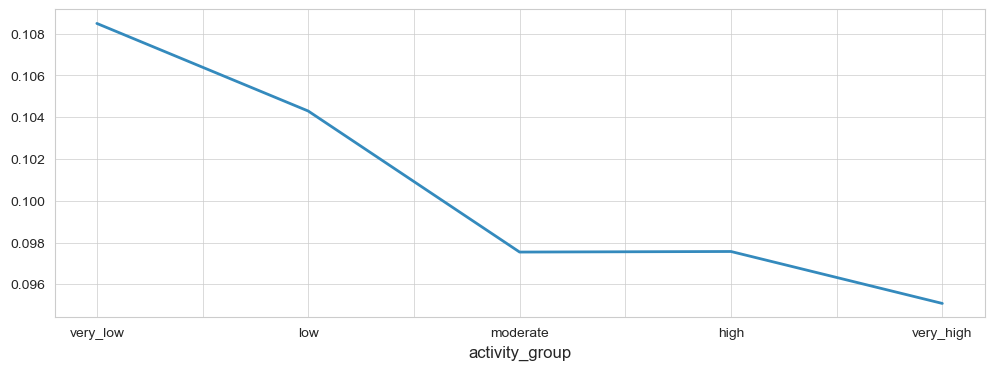

In [49]:
df.groupby('activity_group')['Depression'].mean().plot()

In [50]:
pd.crosstab(
    df['activity_group'],
    df['Depression'],
    normalize='index'
)*100

Depression,0,1
activity_group,,
very_low,89.150897,10.849103
low,89.570186,10.429814
moderate,90.245256,9.754744
high,90.242555,9.757445
very_high,90.491210,9.508790


In [51]:
pd.crosstab(
    df['activity_group'],
    df['Depression'],
)

Depression,0,1
activity_group,,
very_low,17996,2190
low,18026,2099
moderate,17883,1933
high,17970,1943
very_high,17501,1839


In [52]:
df=df.drop(columns=['activity_group'])
df.shape

(100000, 10)

### Exploring CGPA(Acadamic Performance)

<Axes: xlabel='Depression', ylabel='CGPA'>

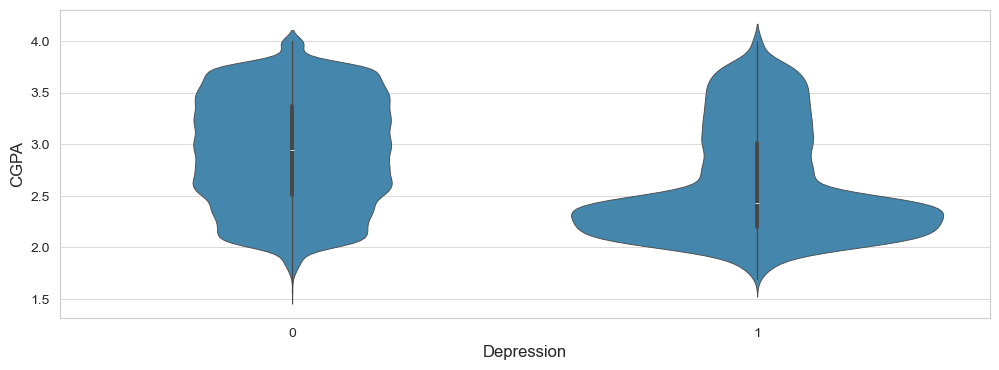

In [54]:
sns.violinplot(
    x='Depression',
    y='CGPA',
    data=df
)

In [55]:
df.groupby('Depression')['CGPA'].agg(
    ['mean','median','std','count']
)

,mean,median,std,count
Depression,,,,
0,2.930177,2.94,0.522991,89938
1,2.613530,2.43,0.529498,10062


<Axes: xlabel='Study_Hours', ylabel='CGPA'>

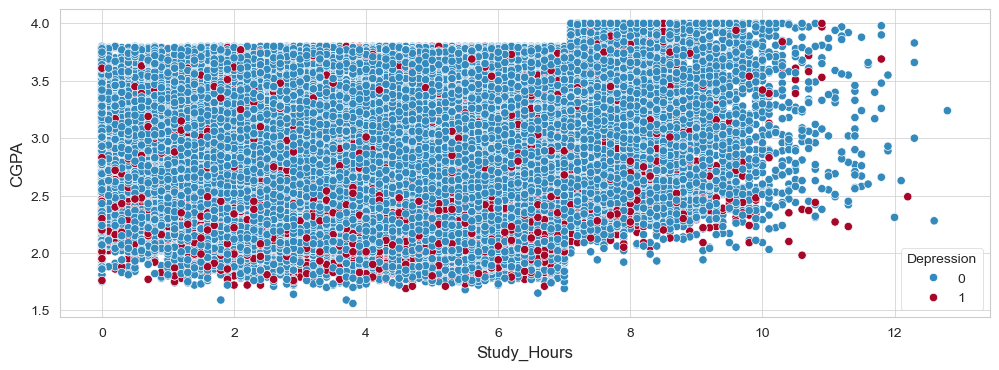

In [56]:
sns.scatterplot(
    x='Study_Hours',
    y='CGPA',
    hue='Depression',
    data=df
)

In [57]:
df['CGPA'].quantile(
    [0,0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,
     0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,0.97,0.99,1]
)

0.00    1.56
0.01    1.93
0.05    2.07
0.10    2.17
0.15    2.27
0.20    2.36
0.25    2.45
0.30    2.54
0.35    2.63
0.40    2.72
0.45    2.81
0.50    2.90
0.55    2.99
0.60    3.08
0.65    3.17
0.70    3.26
0.75    3.35
0.80    3.44
0.85    3.53
0.90    3.63
0.95    3.73
0.97    3.77
0.99    3.89
1.00    4.00
Name: CGPA, dtype: float64

In [58]:
df['new_cgpa']=df['CGPA']*2.5

In [59]:
df['cgpa_group']=pd.cut(
    df['new_cgpa'],
    bins=[3.9,6,8,10],
    labels=['low','good','high']
)
df['cgpa_group'].value_counts(dropna=False)

cgpa_group
good    44452
high    32965
low     22583
Name: count, dtype: int64

In [60]:
df.groupby('cgpa_group')['Depression'].mean()

C:\Users\Afarinesh Pardaz\AppData\Local\Temp\ipykernel_8284\804444370.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('cgpa_group')['Depression'].mean()


cgpa_group
low     0.211929
good    0.076420
high    0.057000
Name: Depression, dtype: float64

In [61]:
pd.crosstab(
    df['cgpa_group'],
    df['Depression'],
    normalize='index'
)*100

Depression,0,1
cgpa_group,,
low,78.807067,21.192933
good,92.358049,7.641951
high,94.300015,5.699985


In [62]:
pd.crosstab(
    df['cgpa_group'],
    df['Depression']
)

Depression,0,1
cgpa_group,,
low,17797,4786
good,41055,3397
high,31086,1879


In [63]:
df.groupby('Depression')['new_cgpa'].agg(
    ['mean','median','std','count']
)

,mean,median,std,count
Depression,,,,
0,7.325442,7.350,1.307478,89938
1,6.533825,6.075,1.323745,10062


<Axes: xlabel='Study_Hours', ylabel='new_cgpa'>

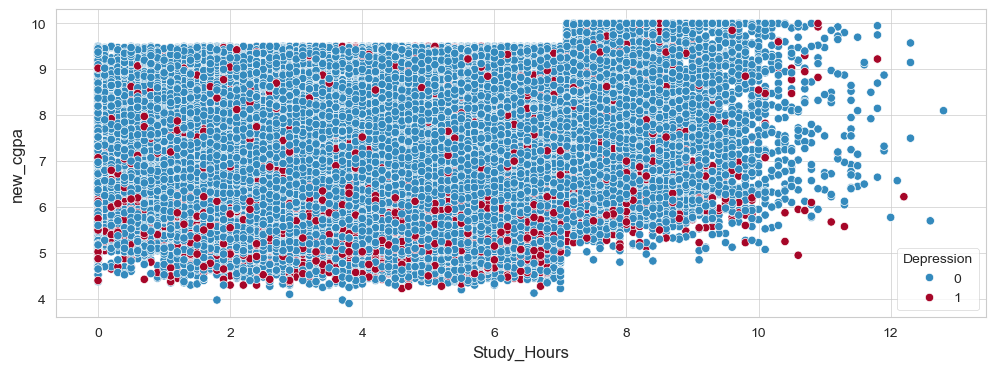

In [64]:
sns.scatterplot(
    x='Study_Hours',
    y='new_cgpa',
    hue='Depression',
    data=df
)

### Study hours breakdown

In [66]:
df['Study_Hours'].describe()

count    100000.000000
mean          4.509517
std           1.976076
min           0.000000
25%           3.200000
50%           4.500000
75%           5.800000
max          12.800000
Name: Study_Hours, dtype: float64

In [67]:
df['study_group']=pd.cut(
    df['Study_Hours'],
    bins=[-1,2,4,6,12.8],
    labels=['low','good','high','great']
)
df['study_group'].value_counts(dropna=False)

study_group
high     37103
good     30080
great    21861
low      10956
Name: count, dtype: int64

In [68]:
df.groupby('Depression')['Study_Hours'].agg(
    ['mean','median','std','count']
)

,mean,median,std,count
Depression,,,,
0,4.520047,4.5,1.980848,89938
1,4.415395,4.4,1.930440,10062


In [69]:
pd.crosstab(
    df['study_group'],
    df['Depression']
)

Depression,0,1
study_group,,
low,9795,1161
good,26986,3094
high,33304,3799
great,19853,2008


In [70]:
pd.crosstab(
    df['study_group'],
    df['Depression'],
    normalize='index'
)*100

Depression,0,1
study_group,,
low,89.403067,10.596933
good,89.714096,10.285904
high,89.760936,10.239064
great,90.814693,9.185307


In [71]:
df.groupby('study_group')['new_cgpa'].agg(
    ['mean','median','std']
)

C:\Users\Afarinesh Pardaz\AppData\Local\Temp\ipykernel_8284\2634217403.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('study_group')['new_cgpa'].agg(


,mean,median,std
study_group,,,
low,7.160216,7.175,1.311910
good,7.169615,7.150,1.312551
high,7.177843,7.175,1.313465
great,7.508809,7.525,1.359913


In [72]:
df.groupby('Department')['Study_Hours'].mean()

Department
Arts           4.504655
Business       4.553430
Engineering    4.481209
Medical        4.501688
Science        4.506876
Name: Study_Hours, dtype: float64

In [73]:
df=df.drop(columns=['new_cgpa','cgpa_group','study_group'])
df.columns

Index(['Age', 'Gender', 'Department', 'CGPA', 'Sleep_Duration', 'Study_Hours',
       'Social_Media_Hours', 'Physical_Activity', 'Stress_Level',
       'Depression'],
      dtype='object')

### Social media usage breakdown

In [75]:
df['Social_Media_Hours'].describe()

count    100000.000000
mean          3.503288
std           1.486852
min           0.000000
25%           2.500000
50%           3.500000
75%           4.500000
max          10.000000
Name: Social_Media_Hours, dtype: float64

In [76]:
df['media_hours_grouped']=pd.cut(
    df['Social_Media_Hours'],
    bins=[-1,2,4,6,10],
    labels=['low','high','very_high','extreme']
)
df['media_hours_grouped'].value_counts(dropna=False)

media_hours_grouped
high         47704
very_high    31127
low          16667
extreme       4502
Name: count, dtype: int64

In [77]:
for column in ['Depression','CGPA','Study_Hours'] :
    print(
        df.groupby('media_hours_grouped')[column].agg(
            ['mean','median','std','count']
        )
    )

                         mean  median       std  count
media_hours_grouped                                   
low                  0.096418     0.0  0.295173  16667
high                 0.096847     0.0  0.295753  47704
very_high            0.107110     0.0  0.309257  31127
extreme              0.111284     0.0  0.314518   4502
                         mean  median       std  count
media_hours_grouped                                   
low                  2.931651    2.93  0.525305  16667
high                 2.925711    2.93  0.527011  47704
very_high            2.862297    2.86  0.537570  31127
extreme              2.733649    2.74  0.530784   4502
                         mean  median       std  count
media_hours_grouped                                   
low                  4.489212     4.5  1.988623  16667
high                 4.498241     4.5  1.963302  47704
very_high            4.534057     4.5  1.989545  31127
extreme              4.534496     4.5  1.969665   4502


C:\Users\Afarinesh Pardaz\AppData\Local\Temp\ipykernel_8284\3743206779.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('media_hours_grouped')[column].agg(
C:\Users\Afarinesh Pardaz\AppData\Local\Temp\ipykernel_8284\3743206779.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('media_hours_grouped')[column].agg(
C:\Users\Afarinesh Pardaz\AppData\Local\Temp\ipykernel_8284\3743206779.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

In [78]:
p=pd.crosstab(
    df['media_hours_grouped'],
    df['Depression']
)
p

Depression,0,1
media_hours_grouped,,
low,15060,1607
high,43084,4620
very_high,27793,3334
extreme,4001,501


In [79]:
pd.crosstab(
    df['media_hours_grouped'],
    df['Depression'],
    normalize='index'
)*100

Depression,0,1
media_hours_grouped,,
low,90.358193,9.641807
high,90.315278,9.684722
very_high,89.289042,10.710958
extreme,88.871613,11.128387


In [80]:
p[0]/p[1]

media_hours_grouped
low          9.371500
high         9.325541
very_high    8.336233
extreme      7.986028
dtype: float64

In [81]:
df=df.drop('media_hours_grouped',axis=1)

## Feature Engineering

In [83]:
df_cop=df.copy()
df_cop.columns

Index(['Age', 'Gender', 'Department', 'CGPA', 'Sleep_Duration', 'Study_Hours',
       'Social_Media_Hours', 'Physical_Activity', 'Stress_Level',
       'Depression'],
      dtype='object')

In [84]:
df_cop=df_cop.drop(columns=['Age','Gender','Department'])
df_cop.dtypes

CGPA                  float64
Sleep_Duration        float64
Study_Hours           float64
Social_Media_Hours    float64
Physical_Activity       int64
Stress_Level            int64
Depression              int32
dtype: object

In [85]:
df_cop.describe()

,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660,0.100620
std,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151,0.300826
min,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000,0.000000
50%,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000,0.000000
75%,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000,0.000000
max,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000,1.000000


In [86]:
#basic scaling for a quick experiment

df_cop['Physical_Activity']=df_cop['Physical_Activity']/12
df_cop['CGPA']=df_cop['CGPA']*2.5

In [87]:
df_cop.describe()

,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,7.245789,6.996425,4.509517,3.503288,6.196098,4.131660,0.100620
std,1.330601,1.498682,1.976076,1.486852,3.613914,1.424151,0.300826
min,3.900000,3.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,6.125000,6.000000,3.200000,2.500000,3.083333,3.000000,0.000000
50%,7.250000,7.000000,4.500000,3.500000,6.166667,4.000000,0.000000
75%,8.375000,8.000000,5.800000,4.500000,9.333333,5.000000,0.000000
max,10.000000,12.000000,12.800000,10.000000,12.416667,10.000000,1.000000


In [88]:
#summing up healthy habits and subtracting unhealthy ones to get into a value which shows
#depression directly

df_cop['result']=(
    df_cop['CGPA']+df_cop['Sleep_Duration']+df_cop['Study_Hours']+df_cop['Physical_Activity']
)-(df_cop['Social_Media_Hours']+df_cop['Stress_Level'])
df_cop['result'].describe()

count    100000.000000
mean         17.312882
std           5.523918
min          -6.066667
25%          13.358333
50%          17.408333
75%          21.341667
max          36.933333
Name: result, dtype: float64

In [89]:
df_cop.groupby('Depression')['result'].agg(
    ['mean','median','std','count']
)

,mean,median,std,count
Depression,,,,
0,17.493225,17.570833,5.463624,89938
1,15.700904,15.775000,5.792177,10062


In [90]:
df_cop['result_group']=pd.cut(
    df_cop['result'],
    bins=[-7,1,8,15,22,29,37],
    labels=['-6_1','1_8','8_15','15_22','22_29','29_37']
)
df_cop['result_group'].value_counts(dropna=False)

result_group
15_22    43952
8_15     30113
22_29    20186
1_8       4537
29_37     1123
-6_1        89
Name: count, dtype: int64

In [91]:
p=pd.crosstab(
    df_cop['result_group'],
    df_cop['Depression']
)
p

Depression,0,1
result_group,,
-6_1,57,32
1_8,3576,961
8_15,26553,3560
15_22,39891,4061
22_29,18795,1391
29_37,1066,57


In [92]:
pd.crosstab(
    df_cop['result_group'],
    df_cop['Depression'],
    normalize='index'
)*100

Depression,0,1
result_group,,
-6_1,64.044944,35.955056
1_8,78.818603,21.181397
8_15,88.177863,11.822137
15_22,90.760375,9.239625
22_29,93.109086,6.890914
29_37,94.924310,5.075690


In [93]:
df_cop['result'].corr(other=df_cop['Depression'])

-0.09760776625506351

In [94]:
#seeing out of how many student we can get depression in each group

p[0]/p[1]

result_group
-6_1      1.781250
1_8       3.721124
8_15      7.458708
15_22     9.822950
22_29    13.511862
29_37    18.701754
dtype: float64

## Clustering

In [96]:
from sklearn.preprocessing import StandardScaler

In [97]:
#taking only important features out

features=[
    'Stress_Level',
    'Physical_Activity',
    'Study_Hours',
    'Sleep_Duration',
    'CGPA',
    'Social_Media_Hours'
]

In [98]:
#scaling data for better clusetering 

scaler=StandardScaler()
X_scaled=scaler.fit_transform(df[features])

In [219]:
from sklearn.cluster import KMeans

kmeans=KMeans(n_clusters=3,random_state=42)
clusters=kmeans.fit_predict(X_scaled)

F:\PyAnaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [221]:
df['cluster']=clusters
df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,cluster
0,22,0,Science,3.50,7.3,3.3,3.4,114,5,0,1
1,20,1,Engineering,2.72,5.5,7.2,6.0,142,2,0,0
2,20,1,Medical,3.01,5.4,2.3,1.8,137,3,0,1
3,21,1,Engineering,3.63,8.1,2.0,4.6,130,3,0,1
4,19,1,Arts,3.14,6.8,2.6,4.3,4,6,0,2


## Clusters Interpretation

In [224]:
df.groupby('cluster')[features].mean()

,Stress_Level,Physical_Activity,Study_Hours,Sleep_Duration,CGPA,Social_Media_Hours
cluster,,,,,,
0,3.464204,92.506397,3.963052,7.368566,2.464280,3.892247
1,3.556196,87.790887,5.113287,7.386096,3.360663,3.111911
2,5.473809,40.265609,4.435283,6.173003,2.858129,3.514251


In [226]:
df['cluster'].value_counts()

cluster
1    34522
0    33845
2    31633
Name: count, dtype: int64

In [228]:
from sklearn.decomposition import PCA

In [230]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

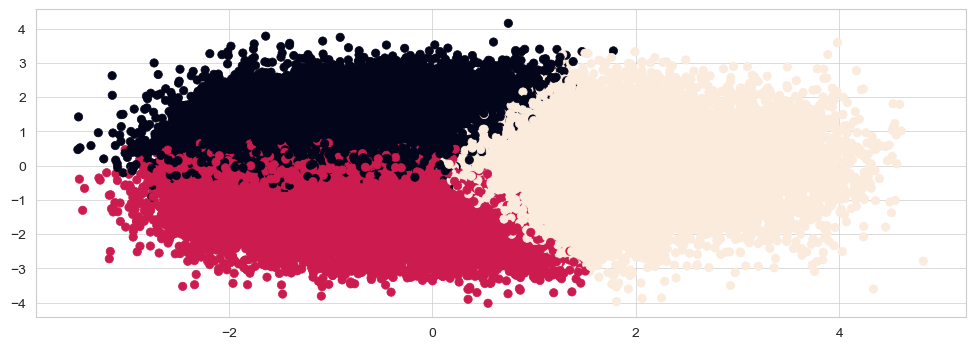

In [232]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

In [233]:
df.groupby('cluster')['Depression'].mean().mul(100).round(2)

cluster
0    13.46
1     5.08
2    11.86
Name: Depression, dtype: float64

In [234]:
p=pd.crosstab(
    df['Depression'],
    df['cluster']
)
p

cluster,0,1,2
Depression,,,
0,29288,32769,27881
1,4557,1753,3752


In [240]:
#this shows the percentage of depressed people divided into these three categories

array=np.array([4557,1753,3752])
array*(100/array.sum())

array([45.28920692, 17.4219837 , 37.28880938])